# Sparse Variational GP with Inducing Points

Sparse GPs approximate the full kernel with $M \ll N$ inducing points:

$$K \approx K_{NM} K_{MM}^{-1} K_{MN}$$

The resulting covariance is $\sigma^2 I + U U^\top$ — a `LowRankUpdate`
in gaussx. We optimize the ELBO with respect to inducing point
locations and kernel hyperparameters via `jax.grad`.

In [1]:
from __future__ import annotations

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import gaussx


jax.config.update("jax_enable_x64", True)

## Generate data

In [2]:
key = jax.random.PRNGKey(123)
k1, k2 = jax.random.split(key)

n_data = 300
noise_std = 0.2

f_true = lambda x: jnp.sin(2 * x) + 0.3 * jnp.cos(5 * x)

x_data = jnp.sort(jax.random.uniform(k1, (n_data,), minval=-4.0, maxval=4.0))
y_data = f_true(x_data) + noise_std * jax.random.normal(k2, (n_data,))

x_plot = jnp.linspace(-4.5, 4.5, 500)

## Build Nystrom approximation

In [3]:
n_inducing = 12


def rbf(x1, x2, ls, var):
    return var * jnp.exp(-0.5 * (x1[:, None] - x2[None, :]) ** 2 / ls**2)


def build_sparse_gp(x_data, x_inducing, ls, var, noise):
    """Build the sparse GP covariance as a LowRankUpdate."""
    K_nm = rbf(x_data, x_inducing, ls, var)
    K_mm = rbf(x_inducing, x_inducing, ls, var)

    # Nystrom: U = K_nm @ chol(K_mm)^{-T}
    jitter = 1e-5 * jnp.eye(len(x_inducing))
    L_mm = jnp.linalg.cholesky(K_mm + jitter)
    U = jax.scipy.linalg.solve_triangular(L_mm, K_nm.T, lower=True).T

    # Sigma = noise * I + U U^T
    return gaussx.low_rank_plus_diag(noise * jnp.ones(len(x_data)), U)


# Initial setup
x_inducing = jnp.linspace(-3.5, 3.5, n_inducing)
ls, var, noise = 1.0, 1.0, noise_std**2

sigma = build_sparse_gp(x_data, x_inducing, ls, var, noise)
print(f"Data: {n_data}, Inducing: {n_inducing}")
print(f"Operator rank: {sigma.rank}")

Data: 300, Inducing: 12
Operator rank: 12


## ELBO (variational lower bound)

$$\mathcal{L} = \log \mathcal{N}(y \mid 0, \sigma^2 I + U U^\top)
              - \frac{1}{2\sigma^2} \mathrm{tr}(K_{NN} - Q_{NN})$$

The first term uses gaussx solve + logdet. The trace correction
penalizes information lost by the approximation.

In [4]:
def elbo(log_params, x_data, y_data, x_inducing):
    ls = jnp.exp(log_params[0])
    var = jnp.exp(log_params[1])
    noise = jnp.exp(log_params[2])

    sigma_op = build_sparse_gp(x_data, x_inducing, ls, var, noise)

    # Log-likelihood term
    alpha = gaussx.solve(sigma_op, y_data)
    data_fit = -0.5 * jnp.dot(y_data, alpha)
    complexity = -0.5 * gaussx.logdet(sigma_op)
    const = -0.5 * len(y_data) * jnp.log(2 * jnp.pi)

    # Trace correction: tr(K_nn - Q_nn) / (2 * noise)
    # K_nn diagonal = var (for RBF with same point)
    # Q_nn diagonal = diag(U U^T)
    Q_diag = jnp.sum(sigma_op.U**2, axis=1)
    trace_correction = -0.5 * jnp.sum(var - Q_diag) / noise

    return data_fit + complexity + const + trace_correction


log_params = jnp.log(jnp.array([ls, var, noise]))
print(f"Initial ELBO: {elbo(log_params, x_data, y_data, x_inducing):.2f}")

Initial ELBO: -165.14


## Optimize hyperparameters

In [5]:
grad_fn = jax.jit(jax.grad(lambda p: -elbo(p, x_data, y_data, x_inducing)))

lr = 0.01
for _i in range(100):
    g = grad_fn(log_params)
    # Clip gradients for stability
    g = jnp.clip(g, -10.0, 10.0)
    log_params = log_params - lr * g

ls_opt, var_opt, noise_opt = jnp.exp(log_params)
print(f"Optimized: ls={ls_opt:.3f}, var={var_opt:.3f}, noise={noise_opt:.4f}")
print(f"Final ELBO: {elbo(log_params, x_data, y_data, x_inducing):.2f}")

Optimized: ls=1.020, var=1.504, noise=0.0922
Final ELBO: -96.68


## Predict

In [6]:
sigma_opt = build_sparse_gp(x_data, x_inducing, ls_opt, var_opt, noise_opt)
alpha_opt = gaussx.solve(sigma_opt, y_data)

# Prediction via inducing points
K_star_m = rbf(x_plot, x_inducing, ls_opt, var_opt)
K_mm = rbf(x_inducing, x_inducing, ls_opt, var_opt)
K_nm = rbf(x_data, x_inducing, ls_opt, var_opt)

weights = jnp.linalg.solve(
    K_mm + 1e-5 * jnp.eye(n_inducing),
    K_nm.T @ alpha_opt,
)
y_pred = K_star_m @ weights

## Visualize

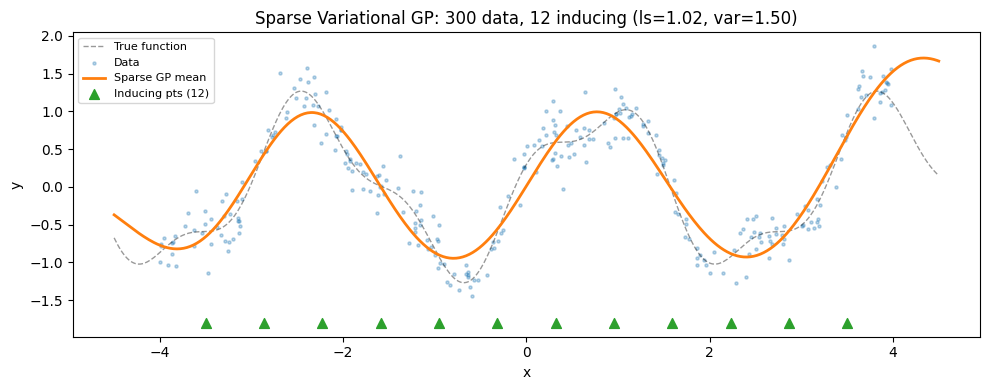

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_plot, f_true(x_plot), "k--", lw=1, alpha=0.4, label="True function")
ax.scatter(x_data, y_data, s=5, c="C0", alpha=0.3, label="Data")
ax.plot(x_plot, y_pred, "C1-", lw=2, label="Sparse GP mean")
ax.scatter(
    x_inducing,
    jnp.full_like(x_inducing, -1.8),
    marker="^",
    s=50,
    c="C2",
    zorder=5,
    label=f"Inducing pts ({n_inducing})",
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(fontsize=8)
ax.set_title(
    f"Sparse Variational GP: {n_data} data, {n_inducing} inducing "
    f"(ls={ls_opt:.2f}, var={var_opt:.2f})"
)
plt.tight_layout()
plt.show()

## Summary

| Component | gaussx role |
|-----------|------------|
| `low_rank_plus_diag` | Build Nystrom covariance |
| `gaussx.solve` | Woodbury solve for weights |
| `gaussx.logdet` | Matrix determinant lemma for ELBO |
| `jax.grad` | Differentiate through everything |